# Au 0,0 Beam Multislice Diagnosis

This notebook isolates the discrepancy between our Au 300 kV multislice 0,0 beam and the paper reference using only multislice-style propagation.

The diagnostics below sweep 25 unit cells and vary only a few likely suspects:
- phase grating formula: refractive index vs sigma V_proj vs abTEM transmission
- scattering parametrization: Weickenmeier-Kohl vs Lobato
- projection model: finite vs infinite
- slices per cell: coarse vs fine

In [32]:
%matplotlib inline

import os
from time import perf_counter

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".30"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from abtem.parametrizations import Parametrization
from ase.build import bulk
from scipy.interpolate import interp1d
from scipy.special import erfc as scipy_erfc

from wide_angle_propagation.wpm import (
    angular_spectrum_propagation_kernel,
    electron_refractive_index,
    energy2sigma,
    energy2wavelength,
    fresnel_propagation_kernel,
    get_abtem_transmit,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

energy = 300e3
a_au = 4.08
gpts = (128, 128)
n_cells_debug = 25
x_debug = np.arange(n_cells_debug + 1, dtype=float)

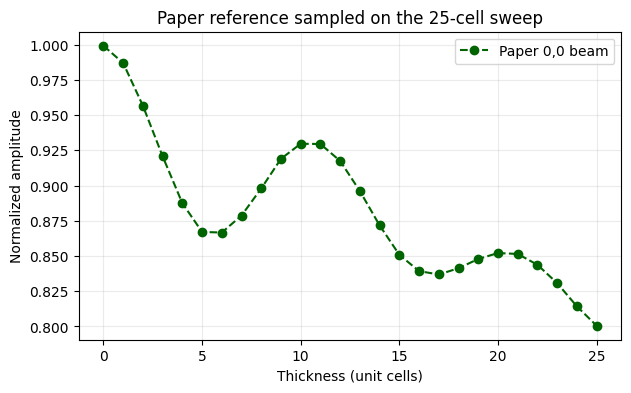

In [33]:
raw_data_Au_Beam_0_0_Klein_Gordon_MS = '''0.06421232876712413, 0.9984732824427482
0.98458904109589, 0.9874045801526719
1.9049657534246576, 0.9599236641221375
2.397260273972603, 0.9431297709923665
3.4460616438356153, 0.9041984732824428
4.216609589041096, 0.8809160305343512
4.880136986301369, 0.867557251908397
5.736301369863013, 0.8641221374045802
6.6138698630137, 0.8725190839694656
7.4486301369863, 0.8858778625954199
8.197773972602743, 0.9022900763358779
8.94691780821918, 0.918320610687023
9.76027397260274, 0.9286259541984734
10.637842465753426, 0.9324427480916031
11.665239726027401, 0.9240458015267177
12.671232876712331, 0.9041984732824428
13.613013698630137, 0.8809160305343513
14.511986301369863, 0.8595419847328245
15.325342465753433, 0.8450381679389314
16.438356164383563, 0.835496183206107
17.529965753424662, 0.8381679389312977
18.728595890410965, 0.8461832061068704
19.58476027397261, 0.8515267175572521
20.71917808219178, 0.8530534351145038
21.72517123287672, 0.8473282442748091
23.073630136986306, 0.8297709923664123
24.14383561643836, 0.8118320610687024
24.807363013698637, 0.8030534351145039'''

def parse_and_interpolate(raw_data):
    data = np.array([[float(val) for val in line.split(',')] for line in raw_data.strip().split('\n')])
    data = data[data[:, 0].argsort()]
    return interp1d(data[:, 0], data[:, 1], kind='linear', fill_value='extrapolate')

paper_beam_00 = parse_and_interpolate(raw_data_Au_Beam_0_0_Klein_Gordon_MS)
paper_curve_debug = paper_beam_00(x_debug)

def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):
    ny, nx = psi_xy.shape
    coeffs = np.fft.fft2(psi_xy) / (nx * ny)
    if use_fftshift:
        coeffs = np.fft.fftshift(coeffs)
        cy, cx = ny // 2, nx // 2
        return np.abs(coeffs[cy + k, cx + h])
    return np.abs(coeffs[k % ny, h % nx])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_debug, paper_curve_debug, 'o--', color='darkgreen', label='Paper 0,0 beam')
ax.set_xlabel('Thickness (unit cells)')
ax.set_ylabel('Normalized amplitude')
ax.set_title(f'Paper reference sampled on the {n_cells_debug}-cell sweep')
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

In [34]:
def weickenmeier_kohl_function(k2, parameters):
    A, B = parameters
    s2 = k2 / 4.0
    s2_expanded = s2[..., None]
    term = -np.expm1(-B * s2_expanded)
    sum_term = np.sum(A * term, axis=-1)
    with np.errstate(divide='ignore', invalid='ignore'):
        f_s = sum_term / s2
    limit_val = np.sum(A * B)
    f_s = np.where(s2 == 0, limit_val, f_s)
    mott_bethe_factor = 47.87801
    return f_s * mott_bethe_factor

def weickenmeier_kohl_potential(r, parameters):
    A, B = parameters
    mott_bethe_factor = 47.87801
    r = np.asarray(r, dtype=np.float64)
    result = np.zeros_like(r)
    for i in range(len(A)):
        result += A[i] * scipy_erfc(2 * np.pi * r / np.sqrt(B[i]))
    with np.errstate(divide='ignore', invalid='ignore'):
        V = mott_bethe_factor * 4 * np.pi * result / r
    V = np.where(r < 1e-14, 1e30, V)
    return V

class WeickenmeierKohlParametrization(Parametrization):
    def __init__(self):
        super().__init__(parameters={})
        self._functions = {
            'elastic': weickenmeier_kohl_function,
            'projected_scattering_factor': weickenmeier_kohl_function,
            'potential': weickenmeier_kohl_potential,
        }

    def scaled_parameters(self, symbol, name):
        if 'Au' not in symbol:
            raise NotImplementedError('Only Au is implemented.')
        Z = 79
        V = 0.4
        B = np.array([5.493e-01, 1.728e+00, 6.720e+00, 2.637e-02, 7.253e-02, 3.546e+01])
        factor = 0.02395 * Z
        a1_val = factor / (3 * (1 + V))
        A = np.array([a1_val, a1_val, a1_val, V * a1_val, V * a1_val, V * a1_val])
        return [A, B]

    def cutoff(self, symbol):
        return 20.0

wk_param = WeickenmeierKohlParametrization()

In [35]:
def to_numpy(arr):
    if isinstance(arr, cupy.ndarray):
        return cupy.asnumpy(arr)
    return np.asarray(arr)

def build_au_bundle(parametrization='lobato', projection='finite', n_slices_per_cell=128):
    atoms = bulk('Au', 'fcc', a=a_au, cubic=True)
    atoms.info['thermal_sigma'] = 0.0
    atoms.arrays['thermal_sigma'] = np.zeros(len(atoms))

    slice_dz = float(atoms.cell[2, 2] / n_slices_per_cell)
    parametrization_obj = wk_param if parametrization == 'wk' else parametrization

    potential = abtem.Potential(
        atoms,
        gpts=gpts,
        slice_thickness=slice_dz,
        projection=projection,
        parametrization=parametrization_obj,
    )

    projected_potential = potential.build(lazy=False).array
    potential_v = jnp.array(to_numpy(projected_potential / slice_dz))
    transmit_abtem = to_numpy(get_abtem_transmit(potential, energy))

    probe = abtem.PlaneWave(energy=energy)
    probe.grid.match(potential)
    psi0 = jnp.array(to_numpy(probe.build(lazy=False).array))
    sampling = (float(probe.grid.sampling[0]), float(probe.grid.sampling[1]))

    kernels = {
        'fresnel': jnp.array(fresnel_propagation_kernel(gpts[0], gpts[1], sampling, z=slice_dz, energy=energy)),
        'as': jnp.array(angular_spectrum_propagation_kernel(gpts[0], gpts[1], sampling, z=slice_dz, energy=energy)),
    }

    return {
        'atoms': atoms,
        'potential_obj': potential,
        'potential_v': potential_v,
        'transmit_abtem': transmit_abtem,
        'psi0': psi0,
        'slice_dz': slice_dz,
        'sampling': sampling,
        'kernels': kernels,
    }

def transmission_exact_n(potential_slice_v, slice_dz):
    wavelength = energy2wavelength(energy)
    n = electron_refractive_index(potential_slice_v, energy)
    return jnp.exp(1j * 2 * jnp.pi * (n - 1.0) * slice_dz / wavelength)

def transmission_sigma(potential_slice_v, slice_dz):
    projected_slice = potential_slice_v * slice_dz
    return jnp.exp(1j * energy2sigma(energy) * projected_slice)

def propagate_wave(wave, kernel):
    return jnp.fft.ifft2(kernel * jnp.fft.fft2(wave))

def run_multislice_beam_sweep(bundle, n_cells, beam_h=0, beam_k=0, propagator='as', phase_mode='sigma'):
    """Multislice sweep recording beam (h, k) amplitude at each unit cell."""
    wave = bundle['psi0']
    kernel = bundle['kernels'][propagator]
    slice_dz = bundle['slice_dz']
    potential_v = bundle['potential_v']
    transmit_abtem = bundle['transmit_abtem']

    amplitudes = [beam_amplitude_normalized(np.asarray(wave), beam_h, beam_k)]

    for _cell in range(n_cells):
        for idx in range(potential_v.shape[0]):
            if phase_mode == 'sigma':
                transmission = transmission_sigma(potential_v[idx], slice_dz)
            elif phase_mode == 'exact_n':
                transmission = transmission_exact_n(potential_v[idx], slice_dz)
            elif phase_mode == 'abtem':
                transmission = jnp.array(transmit_abtem[idx])
            else:
                raise ValueError(f'Unknown phase_mode: {phase_mode}')

            wave = wave * transmission
            wave = propagate_wave(wave, kernel)

        amplitudes.append(beam_amplitude_normalized(np.asarray(wave), beam_h, beam_k))

    return np.array(amplitudes), np.asarray(wave)

def run_beam_sweep_cases(cases, bundle_cache, paper_curve, n_cells, beam_h=0, beam_k=0):
    """Run a list of cases and return curves dict, results DataFrame, and updated bundle_cache."""
    curves = {}
    records = []
    for case in cases:
        cache_key = (case['parametrization'], case['projection'], case['n_slices_per_cell'])
        if cache_key not in bundle_cache:
            print(f'Building potential: {cache_key}')
            bundle_cache[cache_key] = build_au_bundle(*cache_key)

        print(f"Running {case['label']}")
        t0 = perf_counter()
        amplitudes, _ = run_multislice_beam_sweep(
            bundle_cache[cache_key],
            n_cells=n_cells,
            beam_h=beam_h,
            beam_k=beam_k,
            propagator=case['propagator'],
            phase_mode=case['phase_mode'],
        )
        elapsed = perf_counter() - t0

        abs_error = np.abs(amplitudes - paper_curve)
        curves[case['label']] = amplitudes
        records.append({
            'label': case['label'],
            'mean_abs_error': float(np.mean(abs_error[1:])),
            'max_abs_error': float(np.max(abs_error[1:])),
            'error_at_final_cell': float(abs_error[-1]),
            'value_at_final_cell': float(amplitudes[-1]),
            'elapsed_s': elapsed,
        })

    results_df = pd.DataFrame(records).sort_values(['mean_abs_error', 'max_abs_error']).reset_index(drop=True)
    return curves, results_df, bundle_cache

def plot_beam_sweep(curves, paper_curve, x, results_df, beam_label, n_cells):
    """Standard 3-panel output: curves + residuals + bar chart."""
    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    axes[0].plot(x, paper_curve, 'o--', color='darkgreen', linewidth=2, label=f'Paper {beam_label}')
    for label, amplitudes in curves.items():
        axes[0].plot(x, amplitudes, marker='o', ms=3, linewidth=1.5, label=label)
    axes[0].set_ylabel('Normalized amplitude')
    axes[0].set_title(f'{beam_label} beam over the {n_cells}-cell multislice sweep')
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(fontsize=8, ncol=2)

    for label, amplitudes in curves.items():
        axes[1].plot(x, amplitudes - paper_curve, marker='o', ms=3, linewidth=1.5, label=label)
    axes[1].axhline(0.0, color='black', linewidth=1)
    axes[1].set_xlabel('Thickness (unit cells)')
    axes[1].set_ylabel('Computed - paper')
    axes[1].set_title(f'Residual relative to the paper {beam_label} curve')
    axes[1].grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(results_df['label'], results_df['mean_abs_error'], color='steelblue')
    ax.set_xlabel(f'Mean absolute error over cells 1-{n_cells}')
    ax.set_title(f'{beam_label} beam: which knob moves the error the most?')
    ax.grid(True, axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()

def wrapped_phase_difference(a, b):
    return np.angle(np.asarray(a) * np.conj(np.asarray(b)))

In [36]:
cases_00 = [
    {'label': 'WK finite, Fresnel, sigma, 128',       'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 128, 'phase_mode': 'sigma',   'propagator': 'fresnel'},
    {'label': 'WK finite, Fresnel, exact_n, 128',      'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 128, 'phase_mode': 'exact_n', 'propagator': 'fresnel'},
    {'label': 'WK finite, Fresnel, abTEM, 128',        'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 128, 'phase_mode': 'abtem',   'propagator': 'fresnel'},
    {'label': 'WK infinite, Fresnel, sigma, 128',      'parametrization': 'wk', 'projection': 'infinite', 'n_slices_per_cell': 128, 'phase_mode': 'sigma',   'propagator': 'fresnel'},
    {'label': 'WK infinite, Fresnel, exact_n, 128',    'parametrization': 'wk', 'projection': 'infinite', 'n_slices_per_cell': 128, 'phase_mode': 'exact_n', 'propagator': 'fresnel'},
    {'label': 'Lobato finite, Fresnel, sigma, 128',    'parametrization': 'lobato', 'projection': 'finite', 'n_slices_per_cell': 128, 'phase_mode': 'sigma', 'propagator': 'fresnel'},
    {'label': 'WK finite, Fresnel, sigma, 32',         'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 32,  'phase_mode': 'sigma',   'propagator': 'fresnel'},
]

bundle_cache = {}
curves_00, results_00, bundle_cache = run_beam_sweep_cases(
    cases_00, bundle_cache, paper_curve_debug, n_cells_debug, beam_h=0, beam_k=0
)
results_00

Building potential: ('wk', 'finite', 128)
Running WK finite, Fresnel, sigma, 128
Running WK finite, Fresnel, exact_n, 128
Running WK finite, Fresnel, abTEM, 128
Building potential: ('wk', 'infinite', 128)
Running WK infinite, Fresnel, sigma, 128
Running WK infinite, Fresnel, exact_n, 128
Building potential: ('lobato', 'finite', 128)
Running Lobato finite, Fresnel, sigma, 128
Building potential: ('wk', 'finite', 32)
Running WK finite, Fresnel, sigma, 32


,label,mean_abs_error,max_abs_error,error_at_final_cell,value_at_final_cell,elapsed_s
0,"WK infinite, Fresnel, sigma, 128",0.003186,0.007910,0.007553,0.808058,3.394423
1,"WK finite, Fresnel, sigma, 32",0.006215,0.015026,0.001790,0.798715,0.871799
2,"Lobato finite, Fresnel, sigma, 128",0.006559,0.015569,0.000544,0.801049,3.407646
3,"WK finite, Fresnel, sigma, 128",0.006730,0.016332,0.001085,0.801590,4.135567
4,"WK finite, Fresnel, abTEM, 128",0.007113,0.018084,0.000839,0.801344,2.044948
5,"WK finite, Fresnel, exact_n, 128",0.007265,0.017439,0.002669,0.803174,5.491330
6,"WK infinite, Fresnel, exact_n, 128",0.008330,0.022584,0.021060,0.821564,5.532464


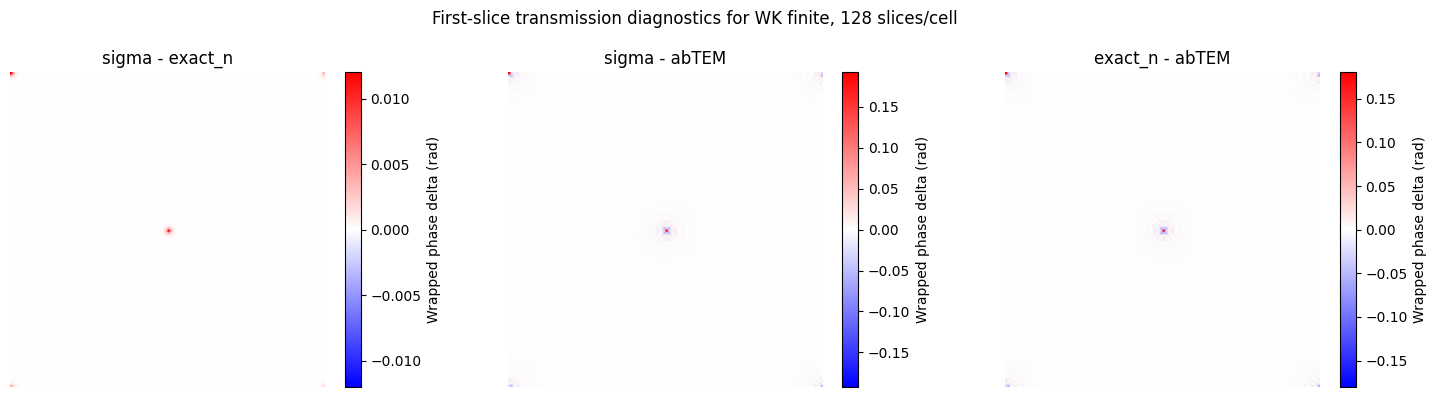

In [37]:
wk_finite_bundle = bundle_cache[('wk', 'finite', 128)]
slice0_v = wk_finite_bundle['potential_v'][0]
slice0_sigma = np.asarray(transmission_sigma(slice0_v, wk_finite_bundle['slice_dz']))
slice0_exact_n = np.asarray(transmission_exact_n(slice0_v, wk_finite_bundle['slice_dz']))
slice0_abtem = np.asarray(wk_finite_bundle['transmit_abtem'][0])

comparison_rows = []
for name_a, trans_a, name_b, trans_b in [
    ('sigma', slice0_sigma, 'exact_n', slice0_exact_n),
    ('sigma', slice0_sigma, 'abtem', slice0_abtem),
    ('exact_n', slice0_exact_n, 'abtem', slice0_abtem),
]:
    complex_delta = trans_a - trans_b
    phase_delta = wrapped_phase_difference(trans_a, trans_b)
    comparison_rows.append({
        'comparison': f'{name_a} vs {name_b}',
        'max_abs_complex_delta': float(np.max(np.abs(complex_delta))),
        'rms_abs_complex_delta': float(np.sqrt(np.mean(np.abs(complex_delta) ** 2))),
        'max_abs_phase_delta_rad': float(np.max(np.abs(phase_delta))),
        'rms_phase_delta_rad': float(np.sqrt(np.mean(phase_delta ** 2))),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
phase_pairs = [
    ('sigma - exact_n', wrapped_phase_difference(slice0_sigma, slice0_exact_n)),
    ('sigma - abTEM', wrapped_phase_difference(slice0_sigma, slice0_abtem)),
    ('exact_n - abTEM', wrapped_phase_difference(slice0_exact_n, slice0_abtem)),
]
for ax, (title, phase_delta) in zip(axes, phase_pairs):
    vmax = np.max(np.abs(phase_delta))
    vmax = max(vmax, 1e-12)
    im = ax.imshow(phase_delta, cmap='bwr', vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, label='Wrapped phase delta (rad)')

fig.suptitle('First-slice transmission diagnostics for WK finite, 128 slices/cell')
plt.tight_layout()
plt.show()

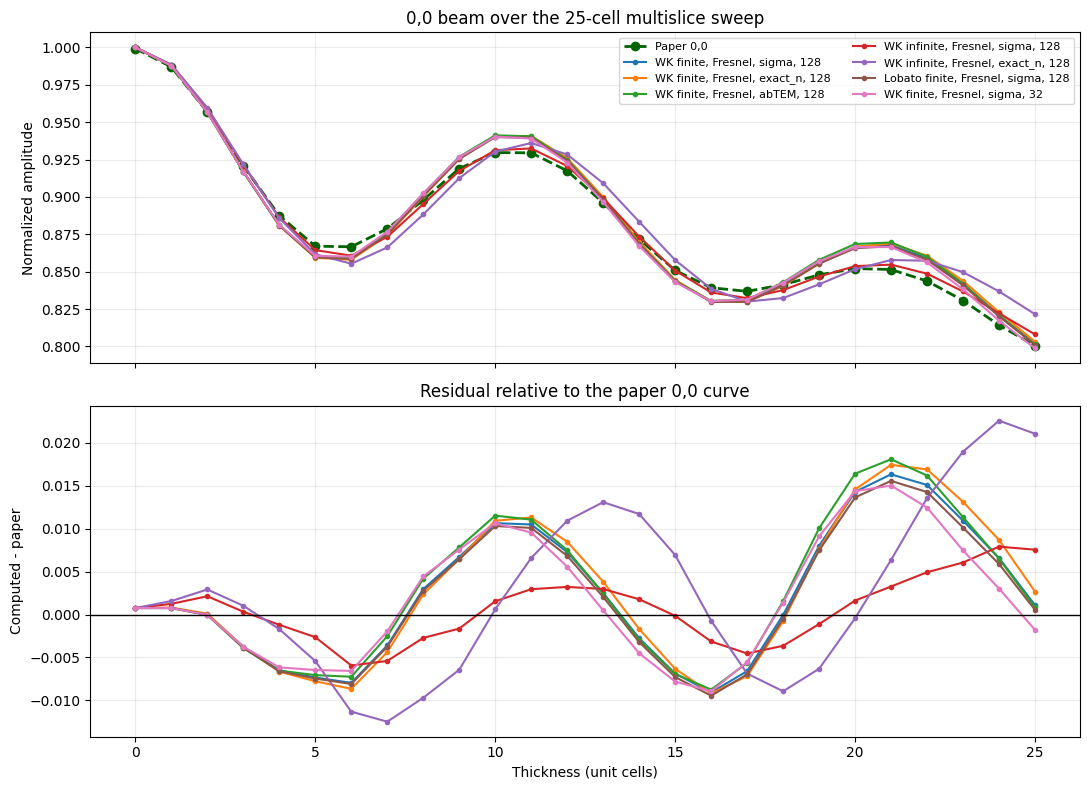

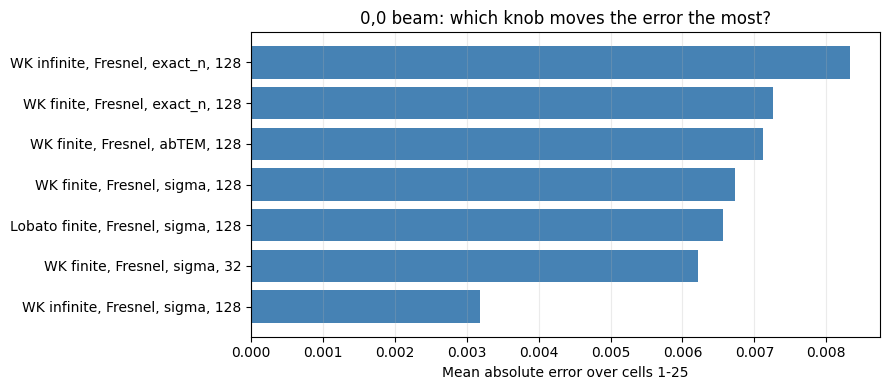

In [38]:
plot_beam_sweep(curves_00, paper_curve_debug, x_debug, results_00, '0,0', n_cells_debug)

In [39]:
best = results_00.iloc[0]
print(f"Best 0,0 match: {best['label']}")
print(f"  mean abs error: {best['mean_abs_error']:.6f}")
print(f"  value at {n_cells_debug} cells: {best['value_at_final_cell']:.6f} (paper: {paper_curve_debug[-1]:.6f})")

Best 0,0 match: WK infinite, Fresnel, sigma, 128
  mean abs error: 0.003186
  value at 25 cells: 0.808058 (paper: 0.800505)


## 0,28 Beam — Fresnel multislice (paper MS reference)

Same parametric sweep but tracking the (0,28) beam with the Fresnel propagator,
compared against the paper's multislice curve for that beam.

In [40]:
raw_data_Au_Beam_0_28_Klein_Gordon_MS = '''0.06620984763060989, 0.00009836065573769898
0.8162989948053649, 0.0008196721311475447
1.478421564942515, 0.0018360655737704873
2.9133055772400027, 0.0044262295081967246
5.253876697410391, 0.009475409836065572
6.732466919170015, 0.011540983606557375
8.12178949701719, 0.012131147540983607
9.796937192201312, 0.011672131147540982
11.870355914071766, 0.013180327868852457
13.613857807846884, 0.015737704918032787
14.606836865488965, 0.016983606557377046
15.841790268019778, 0.017508196721311473
16.76733069264946, 0.016983606557377046
18.177205308352853, 0.015540983606557375
19.939813610123274, 0.014098360655737704
22.034724029259564, 0.01485245901639344
23.071144264222596, 0.015213114754098356
24.085157236341217, 0.015081967213114753
24.92234558263702, 0.014327868852459017'''

raw_data_Au_Beam_0_28_Klein_Gordon_FWD = '''0.22062721060899548, 0.00022950819672130918
0.7942772332571906, 0.000852459016393449
1.500467420321705, 0.0018360655737704942
2.339342334788604, 0.0033770491803278707
3.0016335617428496, 0.004622950819672133
4.680202580931187, 0.008819672131147538
5.828562754792266, 0.011508196721311474
7.373218261196406, 0.013475409836065575
8.475824249959047, 0.013901639344262293
9.798479197386307, 0.013770491803278686
10.768593209394673, 0.013901639344262293
11.915700504042945, 0.014885245901639345
12.908872312333159, 0.01639344262295082
14.41020711057142, 0.01940983606557377
15.05035610682242, 0.020524590163934424
16.373974807490292, 0.02170491803278688
18.093647902391076, 0.02183606557377049
19.32792667765346, 0.02144262295081967
21.35669953065218, 0.02219672131147541
22.901379130887335, 0.024196721311475405
24.0047802160735, 0.02570491803278688
24.93111573712666, 0.02626229508196721'''

paper_beam_028_ms = parse_and_interpolate(raw_data_Au_Beam_0_28_Klein_Gordon_MS)
paper_beam_028_fwd = parse_and_interpolate(raw_data_Au_Beam_0_28_Klein_Gordon_FWD)

paper_028_ms_curve = paper_beam_028_ms(x_debug)
paper_028_fwd_curve = paper_beam_028_fwd(x_debug)

# --- 0,28 Fresnel sweep (vs paper MS curve) ---
cases_028_fresnel = [
    {'label': 'WK finite, Fresnel, sigma, 128',       'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 128, 'phase_mode': 'sigma',   'propagator': 'fresnel'},
    {'label': 'WK finite, Fresnel, exact_n, 128',      'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 128, 'phase_mode': 'exact_n', 'propagator': 'fresnel'},
    {'label': 'WK finite, Fresnel, abTEM, 128',        'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 128, 'phase_mode': 'abtem',   'propagator': 'fresnel'},
    {'label': 'WK infinite, Fresnel, sigma, 128',      'parametrization': 'wk', 'projection': 'infinite', 'n_slices_per_cell': 128, 'phase_mode': 'sigma',   'propagator': 'fresnel'},
    {'label': 'WK infinite, Fresnel, exact_n, 128',    'parametrization': 'wk', 'projection': 'infinite', 'n_slices_per_cell': 128, 'phase_mode': 'exact_n', 'propagator': 'fresnel'},
    {'label': 'Lobato finite, Fresnel, sigma, 128',    'parametrization': 'lobato', 'projection': 'finite', 'n_slices_per_cell': 128, 'phase_mode': 'sigma', 'propagator': 'fresnel'},
    {'label': 'WK finite, Fresnel, sigma, 32',         'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 32,  'phase_mode': 'sigma',   'propagator': 'fresnel'},
]

curves_028_fresnel, results_028_fresnel, bundle_cache = run_beam_sweep_cases(
    cases_028_fresnel, bundle_cache, paper_028_ms_curve, n_cells_debug, beam_h=0, beam_k=28
)
results_028_fresnel

Running WK finite, Fresnel, sigma, 128
Running WK finite, Fresnel, exact_n, 128
Running WK finite, Fresnel, abTEM, 128
Running WK infinite, Fresnel, sigma, 128
Running WK infinite, Fresnel, exact_n, 128
Running Lobato finite, Fresnel, sigma, 128
Running WK finite, Fresnel, sigma, 32


,label,mean_abs_error,max_abs_error,error_at_final_cell,value_at_final_cell,elapsed_s
0,"WK finite, Fresnel, abTEM, 128",0.000267,0.000547,0.000039,0.014219,2.305454
1,"WK finite, Fresnel, sigma, 32",0.000306,0.000618,0.000394,0.013864,0.837114
2,"Lobato finite, Fresnel, sigma, 128",0.000544,0.001116,0.000981,0.013277,4.086900
3,"WK finite, Fresnel, sigma, 128",0.000612,0.001253,0.001112,0.013146,3.435394
4,"WK infinite, Fresnel, sigma, 128",0.000761,0.001710,0.001710,0.012548,3.408005
5,"WK finite, Fresnel, exact_n, 128",0.000785,0.001570,0.001428,0.012830,5.567348
6,"WK infinite, Fresnel, exact_n, 128",0.001922,0.003963,0.003963,0.010294,5.520346


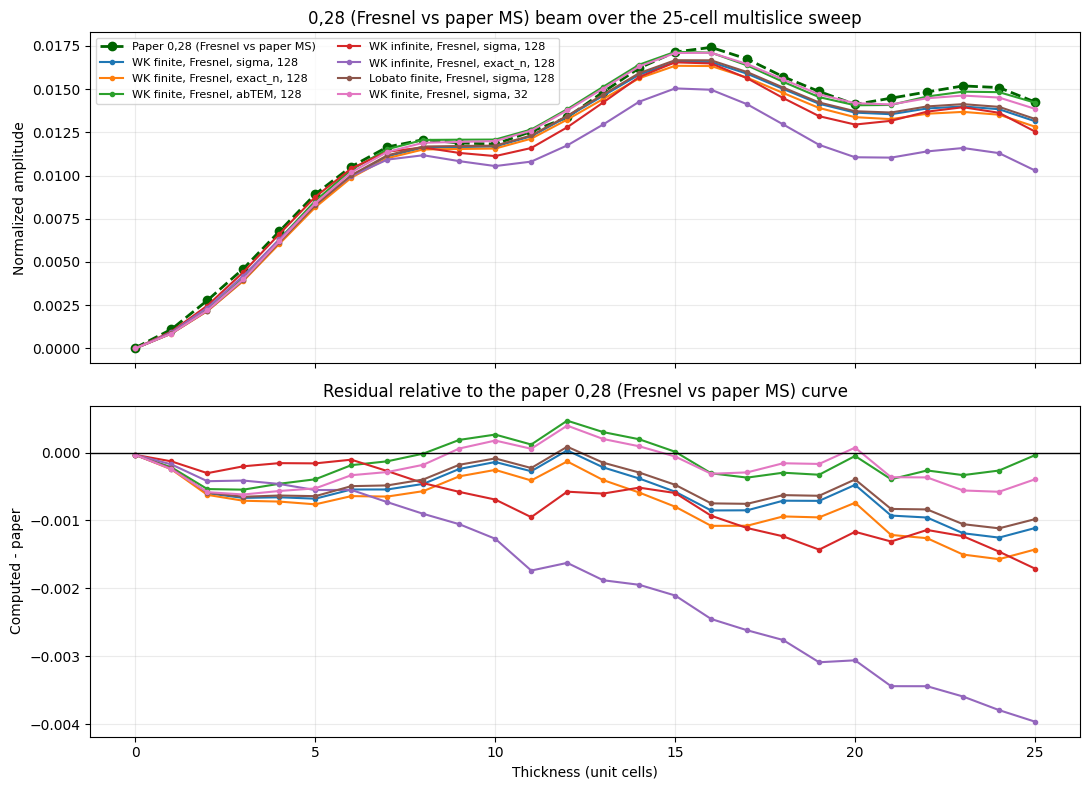

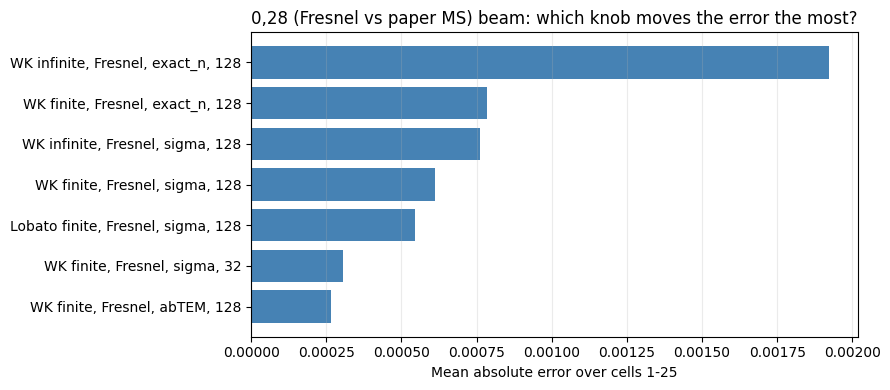

Best 0,28 Fresnel match: WK finite, Fresnel, abTEM, 128
  mean abs error: 2.670906e-04
  value at 25 cells: 1.421907e-02 (paper: 1.425792e-02)


In [41]:
plot_beam_sweep(curves_028_fresnel, paper_028_ms_curve, x_debug, results_028_fresnel, '0,28 (Fresnel vs paper MS)', n_cells_debug)

best = results_028_fresnel.iloc[0]
print(f"Best 0,28 Fresnel match: {best['label']}")
print(f"  mean abs error: {best['mean_abs_error']:.6e}")
print(f"  value at {n_cells_debug} cells: {best['value_at_final_cell']:.6e} (paper: {paper_028_ms_curve[-1]:.6e})")

## 0,28 Beam — Angular Spectrum (paper ODE/FWD reference)

Same parametric sweep but using the angular spectrum propagator and comparing against
the paper's ODE (forward Klein-Gordon) curve for the (0,28) beam.

In [42]:
cases_028_as = [
    {'label': 'WK finite, AS, sigma, 128',       'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 128, 'phase_mode': 'sigma',   'propagator': 'as'},
    {'label': 'WK finite, AS, exact_n, 128',      'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 128, 'phase_mode': 'exact_n', 'propagator': 'as'},
    {'label': 'WK finite, AS, abTEM, 128',        'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 128, 'phase_mode': 'abtem',   'propagator': 'as'},
    {'label': 'WK infinite, AS, sigma, 128',      'parametrization': 'wk', 'projection': 'infinite', 'n_slices_per_cell': 128, 'phase_mode': 'sigma',   'propagator': 'as'},
    {'label': 'WK infinite, AS, exact_n, 128',    'parametrization': 'wk', 'projection': 'infinite', 'n_slices_per_cell': 128, 'phase_mode': 'exact_n', 'propagator': 'as'},
    {'label': 'Lobato finite, AS, sigma, 128',    'parametrization': 'lobato', 'projection': 'finite', 'n_slices_per_cell': 128, 'phase_mode': 'sigma', 'propagator': 'as'},
    {'label': 'WK finite, AS, sigma, 32',         'parametrization': 'wk', 'projection': 'finite',   'n_slices_per_cell': 32,  'phase_mode': 'sigma',   'propagator': 'as'},
]

curves_028_as, results_028_as, bundle_cache = run_beam_sweep_cases(
    cases_028_as, bundle_cache, paper_028_fwd_curve, n_cells_debug, beam_h=0, beam_k=28
)
results_028_as

Running WK finite, AS, sigma, 128
Running WK finite, AS, exact_n, 128
Running WK finite, AS, abTEM, 128
Running WK infinite, AS, sigma, 128
Running WK infinite, AS, exact_n, 128
Running Lobato finite, AS, sigma, 128
Running WK finite, AS, sigma, 32


,label,mean_abs_error,max_abs_error,error_at_final_cell,value_at_final_cell,elapsed_s
0,"WK finite, AS, sigma, 32",0.000868,0.001801,0.001756,0.024548,0.819776
1,"WK finite, AS, abTEM, 128",0.000952,0.002368,0.002293,0.024011,1.934878
2,"Lobato finite, AS, sigma, 128",0.001124,0.002324,0.002311,0.023993,3.225680
3,"WK finite, AS, sigma, 128",0.001207,0.002489,0.002477,0.023826,3.205987
4,"WK infinite, AS, sigma, 128",0.001375,0.002876,0.002876,0.023428,3.198805
5,"WK finite, AS, exact_n, 128",0.001379,0.002826,0.002821,0.023483,5.213179
6,"WK infinite, AS, exact_n, 128",0.002432,0.005192,0.005192,0.021112,5.213568


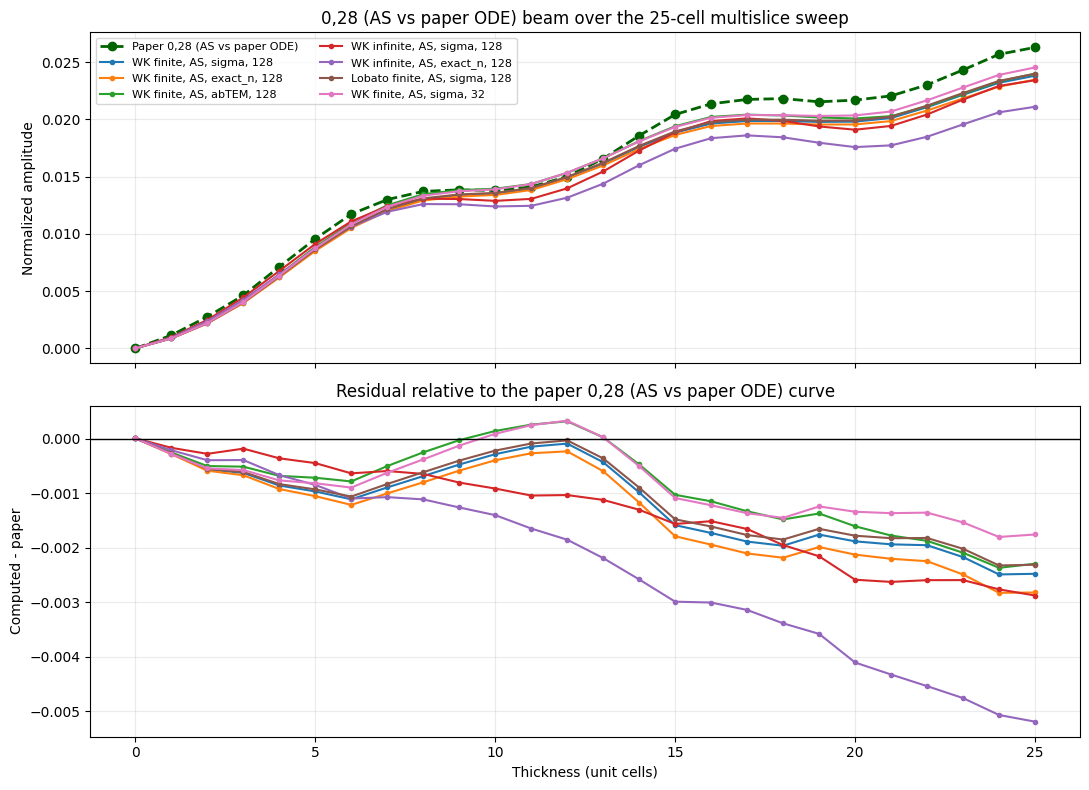

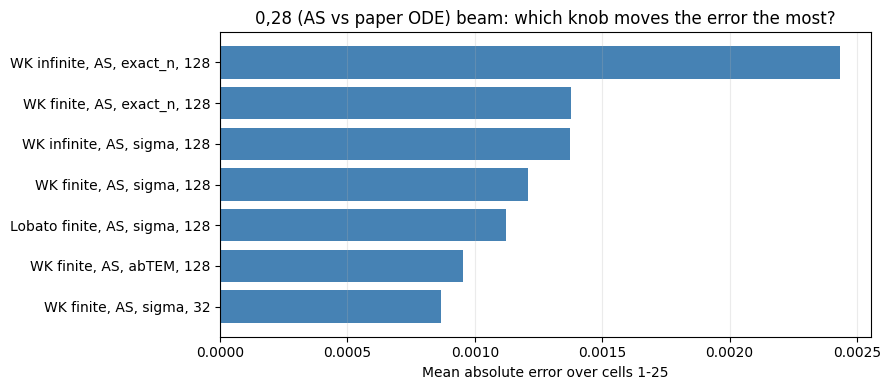

Best 0,28 AS match: WK finite, AS, sigma, 32
  mean abs error: 8.681994e-04
  value at 25 cells: 2.454805e-02 (paper: 2.630374e-02)


: 

In [ ]:
plot_beam_sweep(curves_028_as, paper_028_fwd_curve, x_debug, results_028_as, '0,28 (AS vs paper ODE)', n_cells_debug)

best = results_028_as.iloc[0]
print(f"Best 0,28 AS match: {best['label']}")
print(f"  mean abs error: {best['mean_abs_error']:.6e}")
print(f"  value at {n_cells_debug} cells: {best['value_at_final_cell']:.6e} (paper: {paper_028_fwd_curve[-1]:.6e})")